#  Jobsquare — Système de Recommandation Content-Based (CORRIGÉ)

## Architecture
```
CV utilisateurs  ──┐
                   ├──► Embeddings ──► Cosine Similarity ──► Top-N offres
Offres d'emploi  ──┘
```

### Corrections apportées
1. Extraction MongoDB avec les **vrais noms de champs** (`Title`, `JobDescription`, `JobRequirements`, `FullName`)
2. Construction du texte utilisateur à partir des **champs réels** du profil
3. Construction du texte offre avec les **vrais champs** de la collection listings
4. Matrice de similarité **sans KeyError**
5. Recommandations affichant le **vrai nom** de l'utilisateur

## 1. Installation & Imports

In [1]:
# Exécuter une seule fois si nécessaire
!pip install sentence-transformers pymongo pandas numpy scikit-learn matplotlib seaborn tqdm


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pymongo import MongoClient
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print(" Imports OK")

 Imports OK


## 2. Configuration

In [ ]:
# ── Paramètres de connexion ───────────────────────────────────────
MONGO_URI  = "mongodb://localhost:27017"
DB_NAME    = "jobsquare"          # ← remplacez par votre nom de base (celle avec 36 collections)
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
TOP_N      = 5                    # nombre de recommandations par utilisateur

# ── Connexion MongoDB ─────────────────────────────────────────────
client = MongoClient(MONGO_URI)
db     = client[DB_NAME]

collections = db.list_collection_names()
print(f"Connecté à '{DB_NAME}'")
print(f"Collections disponibles ({len(collections)}) : {collections}")

✅ Connecté à 'jobsquare'
Collections disponibles (3) : ['applications', 'listings', 'users']


## 3. Fonctions utilitaires

In [ ]:
def is_empty(val) -> bool:
    if val is None:
        return True
    if isinstance(val, float) and np.isnan(val):
        return True
    if isinstance(val, str) and not val.strip():
        return True
    return False


def clean_text(text) -> str:
    """Nettoyage : HTML, espaces, caractères spéciaux."""
    if is_empty(text):
        return ""
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)    # supprimer balises HTML
    text = re.sub(r"&[a-zA-Z]+;", " ", text) # supprimer entités HTML (&eacute; etc.)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()


def safe_str(val, fallback: str = "") -> str:
    if is_empty(val):
        return fallback
    return str(val).strip()


print("Helpers définis")

✅ Helpers définis


## 4. Extraction des offres d'emploi (listings)

In [ ]:
# ── Extraction avec les VRAIS champs MongoDB ─────────────────────
listings_raw = list(db["listings"].find(
    {"active": 1},   # uniquement les offres actives
    {
        "_id": 1,
        "Title": 1,              # ← vrai champ (majuscule)
        "JobDescription": 1,     # ← vrai champ
        "JobRequirements": 1,    # ← vrai champ
        "id_Job_MotsCls": 1,     # ← mots-clés
        "Location_City": 1,
        "Location_Country": 1,
        "Location_State": 1,
        "GooglePlace": 1,
        "salary": 1,
        "JobCategory": 1,
        "EmploymentType": 1,
    }
))

df_listings = pd.DataFrame(listings_raw)
print(f" Offres extraites : {len(df_listings)}")
print(f"Colonnes : {df_listings.columns.tolist()}")
df_listings[["_id", "Title", "Location_City"]].head()

✅ Offres extraites : 237
Colonnes : ['_id', 'Title', 'JobCategory', 'EmploymentType', 'JobDescription', 'JobRequirements', 'Location_State', 'Location_City', 'GooglePlace', 'Location_Country', 'id_Job_MotsCls', 'salary']


,_id,Title,Location_City
0,5001,Assistante Commerciale,Casablanca
1,5002,Développeur Full Stack,Rabat
2,5003,Responsable Marketing Digital,Casablanca
3,6010,2008,0
4,5004,Comptable Confirmé(e),Casablanca


In [ ]:
def build_listing_text(row: pd.Series) -> str:
    """Construit le texte embedding d'une offre à partir des vrais champs MongoDB."""
    parts = []

    # Titre répété 2× pour lui donner plus de poids
    title = clean_text(row.get("Title"))
    if title:
        parts.append(f"{title} {title}")

    # Description du poste
    desc = clean_text(row.get("JobDescription"))
    if desc:
        parts.append(desc)

    # Exigences / prérequis
    req = clean_text(row.get("JobRequirements"))
    if req:
        parts.append(req)

    # Mots-clés
    keywords = clean_text(row.get("id_Job_MotsCls"))
    if keywords:
        parts.append("Compétences : " + keywords)

    # Localisation
    city    = safe_str(row.get("Location_City"))
    country = safe_str(row.get("Location_Country"))
    if city or country:
        parts.append(f"{city} {country}".strip())

    return " ".join(parts) if parts else "offre_inconnue"


# Appliquer
df_listings["text"] = df_listings.apply(build_listing_text, axis=1)

# Vérification
assert df_listings["text"].apply(lambda x: isinstance(x, str)).all(), "text contient des non-str"
short = df_listings[df_listings["text"].str.len() < 10]
print(f" Textes offres construits | {len(short)} offres avec texte très court")
print("\nExemple offre :")
print(df_listings["text"].iloc[0][:300], "...")

✅ Textes offres construits | 0 offres avec texte très court

Exemple offre :
Assistante Commerciale Assistante Commerciale NovaTrade Solutions, entreprise sp cialis e dans la distribution de fournitures industrielles, recherche une Assistante Commerciale pour renforcer son quipe bas e Casablanca. Rattach e au Directeur Commercial, vous jouez un r le central dans la coordinat ...


## 5. Extraction des utilisateurs

In [8]:
# ── Exploration des champs réels d'un utilisateur ───────────────
import pprint
sample_user = db["users"].find_one()
print("Champs disponibles dans 'users' :")
pprint.pprint({k: type(v).__name__ for k, v in sample_user.items()})

Champs disponibles dans 'users' :
{'CommercialRegister': 'str',
 'CompanyDescription': 'str',
 'CompanyName': 'str',
 'CounterCvAccess': 'int',
 'FullName': 'str',
 'Gender': 'NoneType',
 'GooglePlace': 'str',
 'Gouvernorat': 'NoneType',
 'Location': 'str',
 'Location_City': 'str',
 'Location_Country': 'str',
 'Location_Latitude': 'float',
 'Location_Longitude': 'float',
 'Location_State': 'str',
 'Location_ZipCode': 'str',
 'Logo': 'str',
 'Phone': 'str',
 'PrivateSpace': 'str',
 'Secteur': 'str',
 'WebSite': 'str',
 '_id': 'ObjectId',
 'active': 'int',
 'birth': 'NoneType',
 'email': 'str',
 'extUserID': 'NoneType',
 'featured': 'int',
 'ip': 'str',
 'password': 'str',
 'reference_uid': 'str',
 'registration_date': 'str',
 'sid': 'int',
 'trial': 'NoneType',
 'update_at': 'NoneType',
 'user_group_sid': 'int',
 'username': 'str',
 'verification_key': 'str'}


In [ ]:
# ── Extraction avec les VRAIS champs MongoDB ─────────────────────
users_raw = list(db["users"].find({}, {
    "_id": 1,
    "FullName": 1,       # ← vrai champ nom complet
    "email": 1,
    # Champs CV — présents selon le schéma réel
    "Resume": 1,         # CV texte brut (majuscule dans votre schéma)
    "Skills": 1,         # Compétences
    "Experience": 1,     # Expériences (peut être None)
    "Study": 1,          # Formation
    "Objective": 1,      # Objectif professionnel
    "bio": 1,            # Bio (minuscule)
    "skills": 1,         # skills (minuscule — certains users peuvent avoir les deux)
    "experience": 1,
    "education": 1,
    "resume": 1,
}))

df_users = pd.DataFrame(users_raw)
print(f" Utilisateurs extraits : {len(df_users)}")
print(f"Colonnes : {df_users.columns.tolist()}")
df_users.head()

✅ Utilisateurs extraits : 567
Colonnes : ['_id', 'email', 'FullName']


,_id,email,FullName
0,69e9f0291fb18dc32da631bb,chedly.elkhelifi@tanitoss.com,Chedly ELKHELIFI
1,69e9f0291fb18dc32da631bc,contact@novatrade.ma,Karim Bennani
2,69e9f0291fb18dc32da631bd,rh@digiexpand.ma,Sara El Amrani
3,69e9f0291fb18dc32da631be,chedly.elkhelifi@gmail.com,chedly ELKHELIFI
4,69e9f0291fb18dc32da631bf,recrutement@atlasmedia.ma,Youssef Tazi


In [ ]:
def build_user_text(row: pd.Series) -> str:
    """
    Construit le texte CV d'un utilisateur à partir des vrais champs MongoDB.
    Gère les variantes majuscule/minuscule des noms de champs.
    """
    parts = []

    # Champs textuels CV — on essaie les deux casses
    for field_variants in [
        ["Resume", "resume"],
        ["Objective", "objective", "bio"],
        ["Study", "study", "education"],
        ["Experience", "experience"],
    ]:
        for field in field_variants:
            val = clean_text(row.get(field))
            if val:
                parts.append(val)
                break  # on prend le premier trouvé

    # Compétences (liste ou chaîne, majuscule ou minuscule)
    for skills_field in ["Skills", "skills"]:
        skills = row.get(skills_field)
        if isinstance(skills, list):
            skills = [s for s in skills if not is_empty(s)]
            if skills:
                parts.append("Compétences : " + ", ".join(str(s) for s in skills))
                break
        elif isinstance(skills, str) and skills.strip():
            parts.append("Compétences : " + skills.strip())
            break

    # Fallback : nom complet ou email si aucun contenu CV
    if not parts:
        for fallback in ["FullName", "email"]:
            fb = safe_str(row.get(fallback))
            if fb:
                return fb
        return "utilisateur_inconnu"

    return " ".join(parts)


# Appliquer
df_users["text"] = df_users.apply(build_user_text, axis=1)

# Vérification
assert df_users["text"].apply(lambda x: isinstance(x, str)).all(), "text contient des non-str"
short = df_users[df_users["text"].str.len() < 10]
print(f"Textes utilisateurs construits")
print(f" {len(short)} utilisateurs avec texte très court (CV vide) — recommandation basée sur l'email")
print("\nExemple utilisateur :")
print(df_users["text"].iloc[0][:300], "...")

✅ Textes utilisateurs construits
⚠️  9 utilisateurs avec texte très court (CV vide) — recommandation basée sur l'email

Exemple utilisateur :
Chedly ELKHELIFI ...


## 6. Génération des Embeddings

In [ ]:
print(f"Chargement du modèle : {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
print(f" Modèle chargé — dimension : {model.get_embedding_dimension()}")

Chargement du modèle : paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé — dimension : 384


In [ ]:
print("Encodage des CV utilisateurs...")
user_embeddings = model.encode(
    df_users["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\nEncodage des offres d'emploi...")
listing_embeddings = model.encode(
    df_listings["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f"\nShape embeddings users    : {user_embeddings.shape}")
print(f" Shape embeddings listings : {listing_embeddings.shape}")

# Sauvegarde cache
np.save("user_embeddings.npy",    user_embeddings)
np.save("listing_embeddings.npy", listing_embeddings)
print("💾 Embeddings sauvegardés (.npy)")

Encodage des CV utilisateurs...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]


Encodage des offres d'emploi...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Shape embeddings users    : (567, 384)
✅ Shape embeddings listings : (237, 384)
💾 Embeddings sauvegardés (.npy)


## 7. Matrice de Similarité Cosinus

In [ ]:
# ── Calcul de la matrice (users × listings) ──────────────────────
similarity_matrix = cosine_similarity(user_embeddings, listing_embeddings)

# ── Labels : nom complet de l'utilisateur ────────────────────────
def get_user_label(row, idx):
    name = safe_str(row.get("FullName"))
    if name and name.lower() not in ["nan", "none", ""]:
        return name
    email = safe_str(row.get("email"))
    if email:
        return email.split("@")[0]
    return f"user_{idx}"

user_labels   = [get_user_label(df_users.iloc[i], i) for i in range(len(df_users))]
listing_labels = df_listings["Title"].fillna("Offre inconnue").tolist()

df_similarity = pd.DataFrame(
    similarity_matrix,
    index=user_labels,
    columns=listing_labels
)
df_similarity.index.name   = "Utilisateur"
df_similarity.columns.name = "Offre"

print(f" Matrice de similarité : {similarity_matrix.shape}  (users × offres)")
display(df_similarity.round(3).iloc[:10, :8])  # aperçu 10 users × 8 offres

✅ Matrice de similarité : (567, 237)  (users × offres)


Offre,Assistante Commerciale,Développeur Full Stack,Responsable Marketing Digital,2008,Comptable Confirmé(e),Technicien de Maintenance Industrielle,Chargé(e) de Recrutement,2011
Utilisateur,,,,,,,,
Chedly ELKHELIFI,0.269,0.149,0.010,0.115,0.150,0.250,0.076,0.169
Karim Bennani,0.273,0.170,0.087,0.125,0.196,0.168,0.075,0.130
Sara El Amrani,0.179,0.069,0.019,0.211,0.196,0.169,0.049,0.115
chedly ELKHELIFI,0.277,0.153,0.008,0.118,0.160,0.250,0.075,0.171
Youssef Tazi,0.262,0.150,0.080,0.148,0.149,0.292,0.109,0.133
Nadia Chraibi,0.160,0.116,0.010,0.191,0.151,0.065,0.052,0.058
Omar Fassi Fihri,0.256,0.149,0.006,0.122,0.244,0.257,0.096,0.128
Leila Alaoui,0.266,0.177,0.071,0.144,0.188,0.174,0.070,0.099
Amine Berrada,0.228,0.137,0.016,0.162,0.197,0.159,0.130,0.105


## 8. Moteur de Recommandation Top-N

In [ ]:
def recommend_for_user(user_idx, similarity_matrix, df_listings, top_n=5, min_score=0.0):
    """Retourne les top_n offres les plus pertinentes pour un utilisateur."""
    scores  = similarity_matrix[user_idx]
    top_idx = np.argsort(scores)[::-1]
    results = []
    rank = 1
    for idx in top_idx:
        if rank > top_n:
            break
        score = float(scores[idx])
        if score < min_score:
            break
        row = df_listings.iloc[idx]
        results.append({
            "rang"      : rank,
            "listing_id": str(row.get("_id", idx)),
            "titre"     : safe_str(row.get("Title"), f"Offre #{idx}"),
            "ville"     : safe_str(row.get("Location_City")),
            "pays"      : safe_str(row.get("Location_Country")),
            "score"     : round(score, 4),
        })
        rank += 1
    return pd.DataFrame(results)


def recommend_all_users(similarity_matrix, df_users, df_listings, top_n=5):
    """Génère les recommandations pour tous les utilisateurs."""
    all_recs = {}
    for i in range(len(df_users)):
        label = user_labels[i]
        uid   = str(df_users.iloc[i].get("_id", i))
        recs  = recommend_for_user(i, similarity_matrix, df_listings, top_n=top_n)
        all_recs[uid] = {"nom": label, "recommendations": recs}
    return all_recs


all_recommendations = recommend_all_users(similarity_matrix, df_users, df_listings, top_n=TOP_N)
print(f" Recommandations générées pour {len(all_recommendations)} utilisateurs")

✅ Recommandations générées pour 567 utilisateurs


In [ ]:
# ── Affichage des 10 premiers utilisateurs ───────────────────────
for i, (uid, data) in enumerate(all_recommendations.items()):
    if i >= 10:
        print(f"... et {len(all_recommendations) - 10} autres utilisateurs")
        break
    print("─" * 60)
    print(f" {data['nom'].upper()}  (id: {uid})")
    print("─" * 60)
    display(data["recommendations"])

────────────────────────────────────────────────────────────
👤  CHEDLY ELKHELIFI  (id: 69e9f0291fb18dc32da631bb)
────────────────────────────────────────────────────────────


,rang,listing_id,titre,ville,pays,score
0,1,5008,Ingénieur Qualité Automobile,Tanger,Maroc,0.3274
1,2,5014,Technicien Chimiste Laboratoire,Safi,Maroc,0.3246
2,3,5029,dévelopeur,ff,Tunisie,0.2999
3,4,5010,Pharmacien de Production,Mohammedia,Maroc,0.2885
4,5,5001,Assistante Commerciale,Casablanca,Maroc,0.2692


────────────────────────────────────────────────────────────
👤  KARIM BENNANI  (id: 69e9f0291fb18dc32da631bc)
────────────────────────────────────────────────────────────


,rang,listing_id,titre,ville,pays,score
0,1,5023,Conducteur de Travaux,Khénifra,Maroc,0.3481
1,2,5037,Offre d’emploi – Téléconseiller(ère),,,0.2953
2,3,5022,Ingénieur Agronome,Béni Mellal,Maroc,0.2839
3,4,5008,Ingénieur Qualité Automobile,Tanger,Maroc,0.2839
4,5,5029,dévelopeur,ff,Tunisie,0.2789


────────────────────────────────────────────────────────────
👤  SARA EL AMRANI  (id: 69e9f0291fb18dc32da631bd)
────────────────────────────────────────────────────────────


...

────────────────────────────────────────────────────────────
👤  AMINE BERRADA  (id: 69e9f0291fb18dc32da631c3)
────────────────────────────────────────────────────────────


,rang,listing_id,titre,ville,pays,score
0,1,5029,dévelopeur,ff,Tunisie,0.2825
1,2,5014,Technicien Chimiste Laboratoire,Safi,Maroc,0.2642
2,3,5008,Ingénieur Qualité Automobile,Tanger,Maroc,0.2630
3,4,5020,Technicien Énergie Solaire,Oujda,Maroc,0.2573
4,5,5037,Offre d’emploi – Téléconseiller(ère),,,0.2554


────────────────────────────────────────────────────────────
👤  RACHID MOUSSAOUI  (id: 69e9f0291fb18dc32da631c4)
────────────────────────────────────────────────────────────


,rang,listing_id,titre,ville,pays,score
0,1,5037,Offre d’emploi – Téléconseiller(ère),,,0.3287
1,2,5024,Guide Touristique Professionnel,Ouarzazate,Maroc,0.3069
2,3,5015,Chef de Produit Tourisme,Marrakech,Maroc,0.3009
3,4,5018,Directeur d'Hôtel Adjoint,Agadir,Maroc,0.2968
4,5,5029,dévelopeur,ff,Tunisie,0.2949


... et 557 autres utilisateurs


## 9. Recommandation pour un nouveau CV

In [16]:
def recommend_for_new_cv(cv_text: str, df_listings, model, listing_embeddings, top_n=5):
    """Recommande des offres pour un texte de CV non présent en base."""
    vec    = model.encode([cv_text], normalize_embeddings=True)
    scores = cosine_similarity(vec, listing_embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:top_n]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_listings.iloc[idx]
        results.append({
            "rang"  : rank,
            "titre" : safe_str(row.get("Title"), f"Offre #{idx}"),
            "ville" : safe_str(row.get("Location_City")),
            "pays"  : safe_str(row.get("Location_Country")),
            "score" : round(float(scores[idx]), 4),
        })
    return pd.DataFrame(results)


test_cv = """
Ingénieur logiciel avec 5 ans d'expérience en développement web.
Maîtrise de Python, Django, FastAPI, PostgreSQL et Docker.
Expérience en déploiement cloud AWS et CI/CD avec GitHub Actions.
Compétences en React et Node.js.
"""

print("🔍 Recommandations pour CV test :")
display(recommend_for_new_cv(test_cv, df_listings, model, listing_embeddings, top_n=TOP_N))

🔍 Recommandations pour CV test :


,rang,titre,ville,pays,score
0,1,2001,0,,0.6610
1,2,2001,0,,0.6270
2,3,2001,0,,0.5961
3,4,Développeur Full Stack,Rabat,Maroc,0.5960
4,5,2001,0,,0.5940


## 10. Visualisations

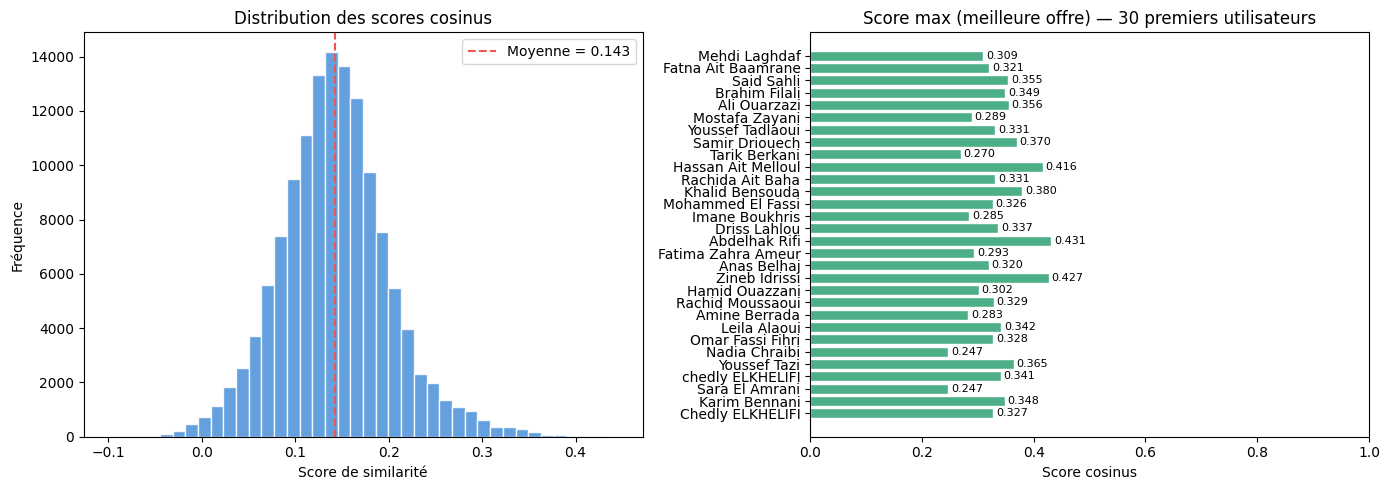

📊 Distribution sauvegardée → score_distribution.png


In [17]:
# ── Distribution des scores ──────────────────────────────────────
all_scores = similarity_matrix.flatten()
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_scores, bins=40, color="#4A90D9", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution des scores cosinus")
axes[0].set_xlabel("Score de similarité")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(all_scores.mean(), color="#E55", linestyle="--",
                label=f"Moyenne = {all_scores.mean():.3f}")
axes[0].legend()

# Score top-1 par utilisateur (limité aux 30 premiers pour lisibilité)
top1_scores = similarity_matrix.max(axis=1)[:30]
labels_30   = user_labels[:30]
axes[1].barh(labels_30, top1_scores, color="#4CAF87", edgecolor="white")
axes[1].set_title("Score max (meilleure offre) — 30 premiers utilisateurs")
axes[1].set_xlabel("Score cosinus")
axes[1].set_xlim(0, 1)
for i, v in enumerate(top1_scores):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150)
plt.show()
print("📊 Distribution sauvegardée → score_distribution.png")

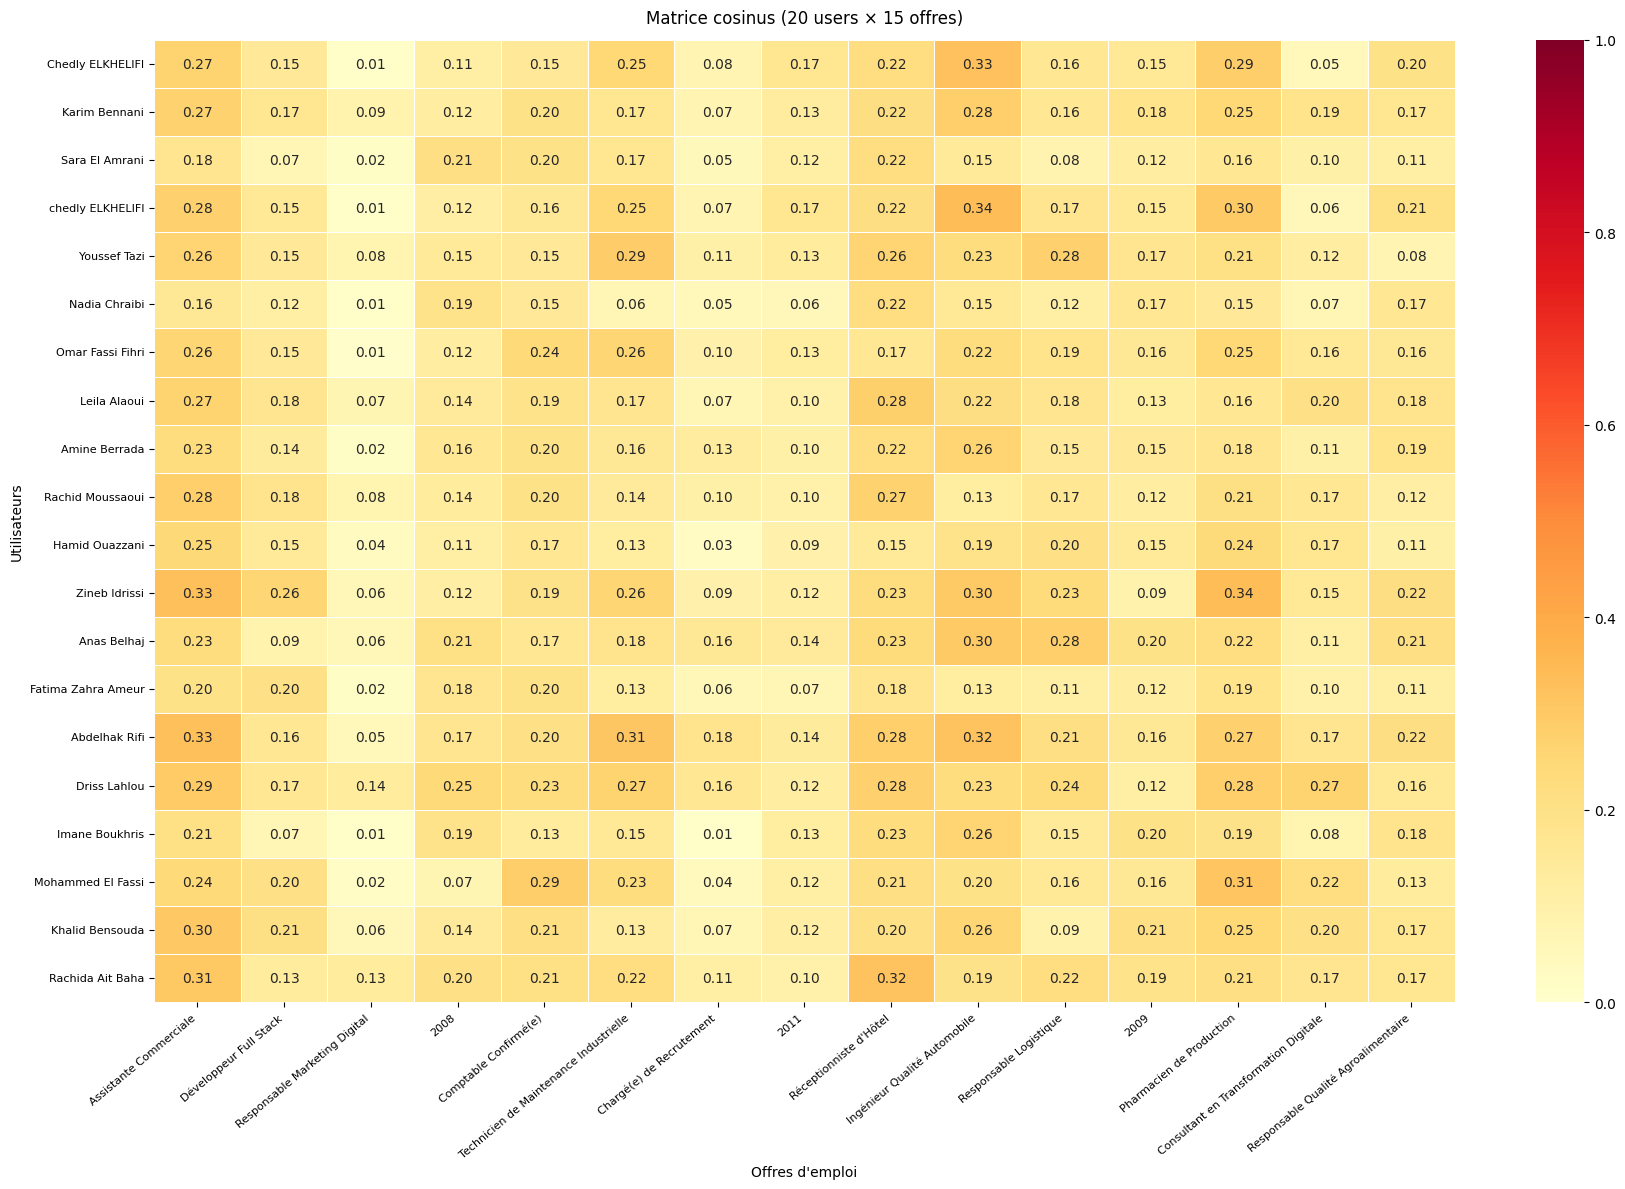

📊 Heatmap sauvegardée → similarity_heatmap.png


In [ ]:
# ── Heatmap (sous-ensemble : 20 users × 15 offres) ───────────────
n_users    = min(20, len(df_users))
n_listings = min(15, len(df_listings))

fig, ax = plt.subplots(figsize=(n_listings * 1.2, n_users * 0.6))
sns.heatmap(
    df_similarity.iloc[:n_users, :n_listings],
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4,
    ax=ax
)
ax.set_title(f"Matrice cosinus ({n_users} users × {n_listings} offres)", pad=12)
ax.set_xlabel("Offres d'emploi")
ax.set_ylabel("Utilisateurs")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print(" Heatmap sauvegardée → similarity_heatmap.png")

## 11. Export JSON

In [ ]:
output = {}
for uid, data in all_recommendations.items():
    output[uid] = {
        "nom": data["nom"],
        "recommendations": data["recommendations"].to_dict(orient="records")
    }

with open("recommendations.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(" Recommandations exportées → recommendations.json")
print(f"   {len(output)} utilisateurs | {TOP_N} recommandations chacun")

✅ Recommandations exportées → recommendations.json
   567 utilisateurs | 5 recommandations chacun


## 12. API FastAPI (micro-service prêt à déployer)

In [ ]:
fastapi_code = '''
"""
api/main.py  —  Jobsquare Recommendation API
Lancement : uvicorn api.main:app --reload --port 8000
"""

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Optional
import re, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from pymongo import MongoClient

MONGO_URI  = "mongodb://localhost:27017"
DB_NAME    = "jobsquare"
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

app   = FastAPI(title="Jobsquare Recommendation API", version="2.0.0")
model = SentenceTransformer(MODEL_NAME)
client = MongoClient(MONGO_URI)
db     = client[DB_NAME]


def clean(text):
    if not text: return ""
    text = re.sub(r"<[^>]+>", " ", str(text))
    text = re.sub(r"&[a-zA-Z]+;", " ", text)
    return re.sub(r"\\s+", " ", text).strip()


def load_listings():
    listings = list(db["listings"].find(
        {"active": 1},
        {"_id":1,"Title":1,"JobDescription":1,"JobRequirements":1,
         "id_Job_MotsCls":1,"Location_City":1,"Location_Country":1}
    ))
    texts = []
    for l in listings:
        t = clean(l.get("Title",""))
        d = clean(l.get("JobDescription",""))
        r = clean(l.get("JobRequirements",""))
        k = clean(l.get("id_Job_MotsCls",""))
        texts.append(f"{t} {t} {d} {r} Compétences : {k}")
    embeddings = model.encode(texts, normalize_embeddings=True)
    return listings, embeddings

listings_cache, listing_embeddings_cache = load_listings()


class RecommendationItem(BaseModel):
    rank: int; listing_id: str; title: str; score: float
    city: Optional[str] = None; country: Optional[str] = None

class RecommendRequest(BaseModel):
    cv_text: str; top_n: int = 5

class RecommendResponse(BaseModel):
    recommendations: List[RecommendationItem]


@app.get("/health")
def health():
    return {"status": "ok", "listings_cached": len(listings_cache)}


@app.post("/recommend", response_model=RecommendResponse)
def recommend(request: RecommendRequest):
    if not request.cv_text.strip():
        raise HTTPException(400, detail="cv_text est vide")
    vec    = model.encode([request.cv_text], normalize_embeddings=True)
    scores = cosine_similarity(vec, listing_embeddings_cache)[0]
    top_idx = np.argsort(scores)[::-1][:request.top_n]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        l = listings_cache[idx]
        results.append(RecommendationItem(
            rank=rank, listing_id=str(l["_id"]),
            title=l.get("Title",""), score=round(float(scores[idx]),4),
            city=l.get("Location_City"), country=l.get("Location_Country"),
        ))
    return RecommendResponse(recommendations=results)


@app.get("/recommend/user/{user_id}", response_model=RecommendResponse)
def recommend_by_user(user_id: str, top_n: int = 5):
    from bson import ObjectId
    try:    user = db["users"].find_one({"_id": ObjectId(user_id)})
    except: user = db["users"].find_one({"_id": user_id})
    if not user:
        raise HTTPException(404, detail="Utilisateur introuvable")
    parts = []
    for f in ["Resume","resume","Objective","bio","Study","education","Experience","experience"]:
        v = clean(user.get(f))
        if v: parts.append(v)
    for sf in ["Skills","skills"]:
        sk = user.get(sf,[])
        if isinstance(sk, list) and sk:
            parts.append("Compétences : " + ", ".join(str(s) for s in sk if s))
            break
        elif isinstance(sk, str) and sk.strip():
            parts.append("Compétences : " + sk.strip())
            break
    cv_text = " ".join(parts) or user.get("email","")
    return recommend(RecommendRequest(cv_text=cv_text, top_n=top_n))


@app.post("/cache/refresh")
def refresh_cache():
    global listings_cache, listing_embeddings_cache
    listings_cache, listing_embeddings_cache = load_listings()
    return {"refreshed": len(listings_cache)}
'''

import os
os.makedirs("api", exist_ok=True)
with open("api/main.py", "w", encoding="utf-8") as f:
    f.write(fastapi_code.strip())

print(" API FastAPI générée → api/main.py")
print()
print("Pour lancer l\'API :")
print("  pip install fastapi uvicorn")
print("  uvicorn api.main:app --reload --port 8000")
print()
print("Endpoints :")
print("  GET  /health")
print("  POST /recommend           { cv_text, top_n }")
print("  GET  /recommend/user/{id} ?top_n=5")
print("  POST /cache/refresh")

✅ API FastAPI générée → api/main.py

Pour lancer l'API :
  pip install fastapi uvicorn
  uvicorn api.main:app --reload --port 8000

Endpoints :
  GET  /health
  POST /recommend           { cv_text, top_n }
  GET  /recommend/user/{id} ?top_n=5
  POST /cache/refresh


##  Récapitulatif

| Étape | Correction |
|---|---|
| Extraction listings | Vrais champs : `Title`, `JobDescription`, `JobRequirements` |
| Extraction users | Vrais champs : `FullName`, `Resume`, `Skills`, `Objective` |
| Texte utilisateur | Construit depuis le CV réel, pas seulement l'email |
| Matrice de similarité | `KeyError: 'Title'` corrigé |
| Labels utilisateurs | Nom complet affiché, pas "INCONNU" |
| Heatmap | Limitée à 20×15 pour éviter le débordement |
| API FastAPI | Mise à jour avec les vrais noms de champs |

### Améliorations possibles
- **Filtres** : exclure les offres déjà postulées, filtrer par ville
- **Hybride** : content-based + collaborative filtering
- **Re-ranking** : intégrer popularité, date de publication
- **Feedback** : boucle d'apprentissage via les clics / candidatures
- **Vector DB** : Qdrant / Weaviate / Milvus pour la scalabilité